In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

In [3]:
print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q4.How many sales transactions were completed using coupons, and how many were completed without using coupons?

In [9]:
from pprint import pprint
pipeline = [
    {
        "$group": {
            "_id": "$couponUsed",
            "Total Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {"Total Transactions": -1}
    }
]

coupon_info = list(collection.aggregate(pipeline))
pprint(coupon_info)

coupon_info_df = pd.DataFrame(coupon_info)
coupon_info_df.rename(columns={"_id": "Coupon Status"}, inplace=True)
coupon_info_df.replace({"Coupon Status": {True: "Coupon Used", False: "Without Coupon"}}, inplace=True)

coupon_info_df

[{'Total Transactions': 4523, '_id': False},
 {'Total Transactions': 477, '_id': True}]


,Coupon Status,Total Transactions
0,Without Coupon,4523
1,Coupon Used,477


## Code for Visualization

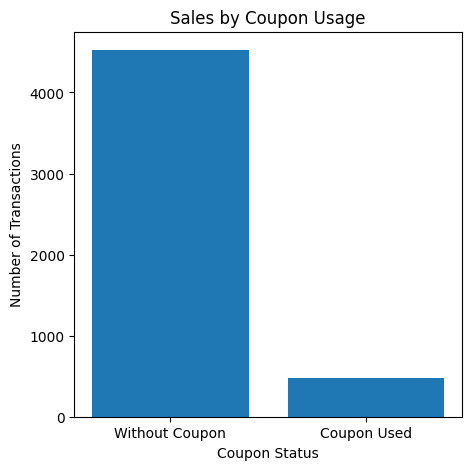

In [12]:
plt.figure(figsize=(5, 5))

plt.bar(coupon_info_df["Coupon Status"], coupon_info_df["Total Transactions"])

plt.title("Sales by Coupon Usage")
plt.xlabel("Coupon Status")
plt.ylabel("Number of Transactions")

plt.show()